# 04 — Final Anomaly Model Selection and Export

This notebook finalizes **Module 3: Anomaly Detection**.

It combines the results from:

- Notebook 2: Unsupervised anomaly detection
- Notebook 3: Supervised anomaly detection

Main objectives:

1. Compare the best unsupervised and supervised models.
2. Select the final anomaly detection model.
3. Build a dashboard-ready alerts table.
4. Define operational risk levels: `NORMAL`, `ALERTE`, and `CRITIQUE`.
5. Export final files for the PFE report and future dashboard integration.


## 1. Imports and directory configuration

In [1]:

import json
import pickle
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

SEED = 42
np.random.seed(SEED)

# Expected notebook location:
# Notebooks/Module 3/Final/04_final_anomaly_model_selection_and_export.ipynb

OUTPUT_DIR = Path('../Final')
FIGURE_DIR = OUTPUT_DIR / 'figures'
REPORT_DIR = OUTPUT_DIR / 'reports'
EXPORT_DIR = OUTPUT_DIR / 'exports'
MODEL_DIR = OUTPUT_DIR / 'models'

for d in [OUTPUT_DIR, FIGURE_DIR, REPORT_DIR, EXPORT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Robust path detection for your project structure
DATA_PREP_CANDIDATES = [
    Path('../Data Preparation'),
    Path('../Module 3 Data Preparation'),
    Path('../../Module 3 Data Preparation'),
    Path('../module3_anomaly_detection/outputs/module3/data'),
]

UNSUP_CANDIDATES = [
    Path('../Unsupervised'),
    Path('../Module 3 Unsupervised Models'),
    Path('../../Module 3 Unsupervised Models'),
]

SUP_CANDIDATES = [
    Path('../Supervised'),
    Path('../Module 3 Supervised Models'),
    Path('../../Module 3 Supervised Models'),
]

def first_existing(candidates, required_file=None):
    for p in candidates:
        if required_file is None and p.exists():
            return p
        if required_file is not None and (p / required_file).exists():
            return p
    return candidates[0]

DATA_PREP_DIR = first_existing(DATA_PREP_CANDIDATES, 'order_level_anomaly_dataset.csv')
UNSUP_DIR = first_existing(UNSUP_CANDIDATES, 'metrics/unsupervised_metrics.csv')
SUP_DIR = first_existing(SUP_CANDIDATES, 'metrics/supervised_metrics.csv')

DATA_PATH = DATA_PREP_DIR / 'order_level_anomaly_dataset.csv'
SCHEMA_PATH = DATA_PREP_DIR / 'anomaly_feature_schema.json'

UNSUP_METRICS_PATH = UNSUP_DIR / 'metrics' / 'unsupervised_metrics.csv'
UNSUP_ALL_MODES_PATH = UNSUP_DIR / 'metrics' / 'unsupervised_metrics_all_threshold_modes.csv'
UNSUP_PREDICTIONS_PATH = UNSUP_DIR / 'predictions' / 'unsupervised_predictions.csv'

SUP_METRICS_PATH = SUP_DIR / 'metrics' / 'supervised_metrics.csv'
SUP_ALL_MODES_PATH = SUP_DIR / 'metrics' / 'supervised_metrics_all_threshold_modes.csv'
SUP_PREDICTIONS_PATH = SUP_DIR / 'predictions' / 'supervised_predictions.csv'
SUP_PER_TYPE_PATH = SUP_DIR / 'metrics' / 'supervised_per_anomaly_type_recall.csv'
SUP_FEATURE_IMPORTANCE_PATH = SUP_DIR / 'metrics' / 'supervised_feature_importance.csv'
SUP_METADATA_PATH = SUP_DIR / 'models' / 'supervised_model_metadata.json'
SUP_BEST_MODEL_PATH = SUP_DIR / 'models' / 'best_supervised_model.pkl'
SUP_PREPROCESSOR_PATH = SUP_DIR / 'models' / 'supervised_preprocessor.pkl'

print('DATA_PREP_DIR:', DATA_PREP_DIR.resolve())
print('UNSUP_DIR:', UNSUP_DIR.resolve())
print('SUP_DIR:', SUP_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())


DATA_PREP_DIR: C:\Users\slimc\Desktop\Notebooks\Module 3\Data Preparation
UNSUP_DIR: C:\Users\slimc\Desktop\Notebooks\Module 3\Unsupervised
SUP_DIR: C:\Users\slimc\Desktop\Notebooks\Module 3\Supervised
OUTPUT_DIR: C:\Users\slimc\Desktop\Notebooks\Module 3\Final


## 2. Load prepared data, metrics, and predictions

In [2]:

def check_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')
    return path

for p in [DATA_PATH, UNSUP_METRICS_PATH, SUP_METRICS_PATH, SUP_PREDICTIONS_PATH]:
    check_file(p)

orders = pd.read_csv(DATA_PATH)
unsup_metrics = pd.read_csv(UNSUP_METRICS_PATH)
sup_metrics = pd.read_csv(SUP_METRICS_PATH)
sup_predictions = pd.read_csv(SUP_PREDICTIONS_PATH)

unsup_all_modes = pd.read_csv(UNSUP_ALL_MODES_PATH) if UNSUP_ALL_MODES_PATH.exists() else pd.DataFrame()
sup_all_modes = pd.read_csv(SUP_ALL_MODES_PATH) if SUP_ALL_MODES_PATH.exists() else pd.DataFrame()
unsup_predictions = pd.read_csv(UNSUP_PREDICTIONS_PATH) if UNSUP_PREDICTIONS_PATH.exists() else pd.DataFrame()
sup_per_type = pd.read_csv(SUP_PER_TYPE_PATH) if SUP_PER_TYPE_PATH.exists() else pd.DataFrame()
sup_feature_importance = pd.read_csv(SUP_FEATURE_IMPORTANCE_PATH) if SUP_FEATURE_IMPORTANCE_PATH.exists() else pd.DataFrame()

print('Orders shape:', orders.shape)
print('Unsupervised metrics:', unsup_metrics.shape)
print('Supervised metrics:', sup_metrics.shape)
print('Supervised predictions:', sup_predictions.shape)

display(sup_metrics.head())


Orders shape: (63049, 77)
Unsupervised metrics: (8, 26)
Supervised metrics: (7, 26)
Supervised predictions: (66206, 12)


,model,split,threshold_mode,threshold,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,false_alerts,missed_anomalies,alert_count,alert_rate,precision_at_50,recall_at_50,anomalies_found_at_50,precision_at_100,recall_at_100,anomalies_found_at_100,precision_at_200,recall_at_200,anomalies_found_at_200
0,Random Forest,test,balanced_f1,0.254509,0.964912,0.937500,0.951009,0.976973,0.999372,9276,6,11,165,6,11,171,0.018080,1.0,0.284091,50,1.0,0.568182,100,0.830,0.943182,166
1,Extra Trees,test,balanced_f1,0.382967,0.964706,0.931818,0.947977,0.979500,0.999505,9276,6,12,164,6,12,170,0.017974,1.0,0.284091,50,1.0,0.568182,100,0.840,0.954545,168
2,HistGradientBoosting,test,balanced_f1,0.915457,0.975904,0.920455,0.947368,0.975152,0.999268,9278,4,14,162,4,14,166,0.017551,1.0,0.284091,50,1.0,0.568182,100,0.825,0.937500,165
3,XGBoost,test,balanced_f1,0.960128,0.993750,0.903409,0.946429,0.978580,0.999382,9281,1,17,159,1,17,160,0.016917,1.0,0.284091,50,1.0,0.568182,100,0.830,0.943182,166
4,CatBoost,test,balanced_f1,0.732291,0.953488,0.931818,0.942529,0.978288,0.999371,9274,8,12,164,8,12,172,0.018186,1.0,0.284091,50,1.0,0.568182,100,0.840,0.954545,168


## 3. Compare best unsupervised and supervised models

In [3]:

# Select best unsupervised and supervised rows by F1-score.
# F1 is used here because the previous notebooks already selected thresholds using balanced_f1.

best_unsup = unsup_metrics.sort_values(['f1', 'recall', 'precision'], ascending=False).iloc[0].copy()
best_sup = sup_metrics.sort_values(['f1', 'recall', 'precision'], ascending=False).iloc[0].copy()

comparison_rows = []
for family, row in [('Best Unsupervised', best_unsup), ('Best Supervised', best_sup)]:
    comparison_rows.append({
        'family': family,
        'model': row['model'],
        'precision': row['precision'],
        'recall': row['recall'],
        'f1': row['f1'],
        'pr_auc': row.get('pr_auc', np.nan),
        'roc_auc': row.get('roc_auc', np.nan),
        'false_alerts': row.get('false_alerts', np.nan),
        'missed_anomalies': row.get('missed_anomalies', np.nan),
        'alert_count': row.get('alert_count', np.nan),
        'alert_rate': row.get('alert_rate', np.nan),
    })

final_comparison = pd.DataFrame(comparison_rows)
final_comparison.to_csv(EXPORT_DIR / 'final_unsupervised_vs_supervised_comparison.csv', index=False)

display(final_comparison)


,family,model,precision,recall,f1,pr_auc,roc_auc,false_alerts,missed_anomalies,alert_count,alert_rate
0,Best Unsupervised,Hybrid Unsupervised Anomaly Detector,0.805825,0.943182,0.869110,0.952129,0.998923,40,10,206,0.021781
1,Best Supervised,Random Forest,0.964912,0.937500,0.951009,0.976973,0.999372,6,11,171,0.018080


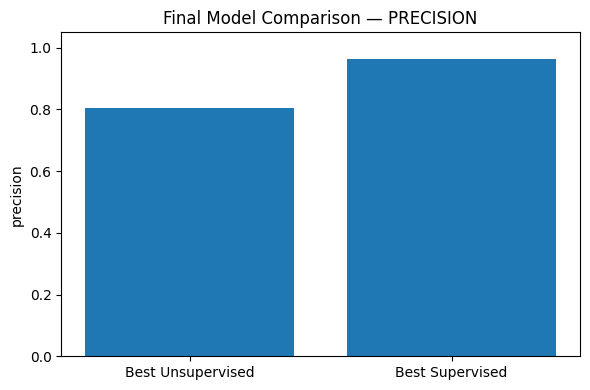

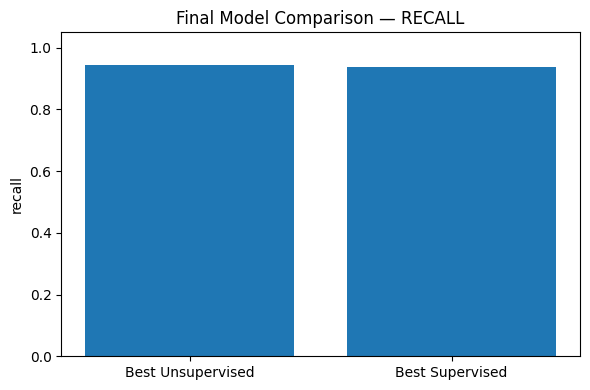

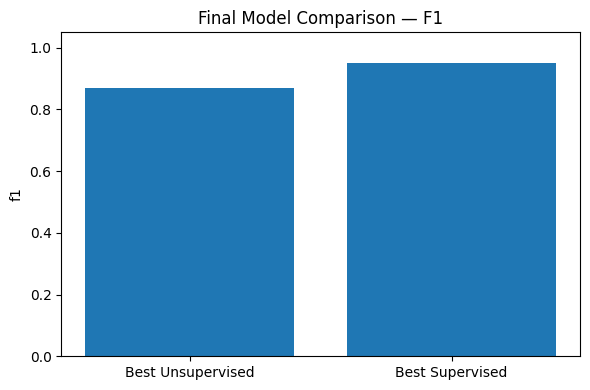

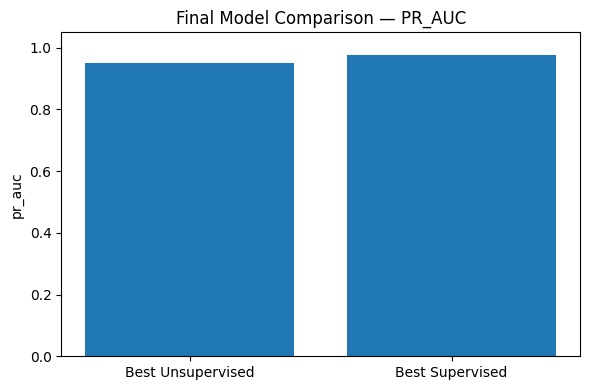

In [4]:

metrics_to_plot = ['precision', 'recall', 'f1', 'pr_auc']
plot_df = final_comparison.copy()

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(plot_df['family'], plot_df[metric])
    plt.title(f'Final Model Comparison — {metric.upper()}')
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'final_comparison_{metric}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4. Select the final model

In [5]:

# Final model selection rule:
# 1. Use the best supervised model because supervised learning achieved stronger final results.
# 2. Use the model with the highest F1-score among supervised candidates.
# 3. Keep precision and recall both high for operational POS alerting.

final_model_row = best_sup.copy()
FINAL_MODEL_NAME = str(final_model_row['model'])
FINAL_THRESHOLD = float(final_model_row['threshold']) if 'threshold' in final_model_row else float(final_model_row.get('best_threshold', 0.5))

final_selection = pd.DataFrame([{
    'selected_model': FINAL_MODEL_NAME,
    'selected_family': 'Supervised',
    'selected_threshold': FINAL_THRESHOLD,
    'precision': float(final_model_row['precision']),
    'recall': float(final_model_row['recall']),
    'f1': float(final_model_row['f1']),
    'pr_auc': float(final_model_row.get('pr_auc', np.nan)),
    'roc_auc': float(final_model_row.get('roc_auc', np.nan)),
    'false_alerts': int(final_model_row.get('false_alerts', -1)),
    'missed_anomalies': int(final_model_row.get('missed_anomalies', -1)),
    'selection_reason': 'Highest supervised F1-score with strong precision-recall balance.'
}])

final_selection.to_csv(EXPORT_DIR / 'final_model_selection_summary.csv', index=False)
display(final_selection)

print(f'Final selected anomaly model: {FINAL_MODEL_NAME}')
print(f'Final threshold: {FINAL_THRESHOLD:.4f}')


,selected_model,selected_family,selected_threshold,precision,recall,f1,pr_auc,roc_auc,false_alerts,missed_anomalies,selection_reason
0,Random Forest,Supervised,0.254509,0.964912,0.9375,0.951009,0.976973,0.999372,6,11,Highest supervised F1-score with strong precis...


Final selected anomaly model: Random Forest
Final threshold: 0.2545


## 5. Build final dashboard-ready anomaly alerts

In [6]:

# Keep only predictions for the selected final model
final_predictions = sup_predictions[sup_predictions['model'].eq(FINAL_MODEL_NAME)].copy()

if final_predictions.empty:
    raise ValueError(f'No predictions found for final model: {FINAL_MODEL_NAME}')

# Merge predictions with the full prepared order-level dataset to add explainability features.
# Avoid duplicate columns by keeping only missing columns from orders.
base_cols = set(final_predictions.columns)
extra_cols = [c for c in orders.columns if c not in base_cols or c == 'order_id']
final_alerts = final_predictions.merge(orders[extra_cols], on='order_id', how='left', suffixes=('', '_order'))

# Use anomaly_score if available; otherwise fallback to probability column names.
score_col = 'anomaly_score'
if score_col not in final_alerts.columns:
    candidate_scores = [c for c in final_alerts.columns if 'score' in c.lower() or 'prob' in c.lower()]
    if candidate_scores:
        score_col = candidate_scores[0]
    else:
        raise ValueError('No anomaly score column found in supervised predictions.')

# Operational thresholds
medium_threshold = FINAL_THRESHOLD
alert_scores = final_alerts.loc[final_alerts['predicted_is_anomaly'].eq(1), score_col]
if len(alert_scores) > 0:
    high_threshold = max(float(alert_scores.quantile(0.75)), medium_threshold)
else:
    high_threshold = min(1.0, medium_threshold + 0.20)

# Keep high threshold readable and stable if probabilities are extreme
high_threshold = float(np.clip(high_threshold, medium_threshold, 0.999))

print('Medium alert threshold:', round(medium_threshold, 4))
print('Critical alert threshold:', round(high_threshold, 4))

def assign_risk_level(score):
    if score < medium_threshold:
        return 'NORMAL'
    if score >= high_threshold:
        return 'CRITIQUE'
    return 'ALERTE'

final_alerts['risk_level'] = final_alerts[score_col].apply(assign_risk_level)
final_alerts['risk_priority'] = final_alerts['risk_level'].map({'CRITIQUE': 3, 'ALERTE': 2, 'NORMAL': 1})

# Business explanation rules for dashboard display
basket_threshold = orders['basket_size'].quantile(0.99) if 'basket_size' in orders.columns else None
amount_threshold = orders['total_amount'].quantile(0.99) if 'total_amount' in orders.columns else None

def get_first_existing(row, columns, default=0):
    for c in columns:
        if c in row.index and pd.notna(row[c]):
            return row[c]
    return default

def build_explanation(row):
    reasons = []
    max_discount = get_first_existing(row, ['max_discount_rate', 'discount_rate', 'max_discount_pct'], 0)
    price_dev = get_first_existing(row, ['max_abs_price_deviation_pct', 'price_deviation_pct', 'max_price_deviation_pct'], 0)
    is_voided = get_first_existing(row, ['is_voided_order', 'is_voided'], 0)
    is_odd_hour = get_first_existing(row, ['is_odd_hour'], 0)
    basket_size = get_first_existing(row, ['basket_size'], 0)
    total_amount = get_first_existing(row, ['total_amount'], 0)
    cashier_id = get_first_existing(row, ['cashier_id'], '')

    try:
        if float(max_discount) >= 0.50:
            reasons.append('high discount')
    except Exception:
        pass
    try:
        if float(price_dev) >= 0.25:
            reasons.append('price deviation')
    except Exception:
        pass
    try:
        if int(is_voided) == 1 or is_voided is True:
            reasons.append('voided order')
    except Exception:
        pass
    try:
        if int(is_odd_hour) == 1:
            reasons.append('odd-hour transaction')
    except Exception:
        pass
    try:
        if basket_threshold is not None and float(basket_size) >= basket_threshold:
            reasons.append('unusual basket size')
    except Exception:
        pass
    try:
        if amount_threshold is not None and float(total_amount) >= amount_threshold:
            reasons.append('high transaction amount')
    except Exception:
        pass
    if str(cashier_id) == 'C07':
        reasons.append('high-risk cashier pattern')

    if not reasons and row.get('predicted_is_anomaly', 0) == 1:
        reasons.append('high model anomaly probability')
    if not reasons:
        reasons.append('normal behavior')
    return '; '.join(reasons)

final_alerts['alert_explanation'] = final_alerts.apply(build_explanation, axis=1)

# Dashboard-ready alerts only
alerts_dashboard = final_alerts[final_alerts['predicted_is_anomaly'].eq(1)].copy()
alerts_dashboard = alerts_dashboard.sort_values(['risk_priority', score_col], ascending=[False, False])

preferred_cols = [
    'order_id', 'order_datetime', 'cashier_id', 'customer_id', 'total_amount',
    'risk_level', score_col, 'predicted_is_anomaly', 'is_anomaly', 'anomaly_type',
    'alert_explanation', 'threshold', 'threshold_mode', 'model'
]
preferred_cols = [c for c in preferred_cols if c in alerts_dashboard.columns]
alerts_dashboard = alerts_dashboard[preferred_cols]

display(alerts_dashboard.head(20))
print('Final alert count:', len(alerts_dashboard))
print('Alert rate:', f"{len(alerts_dashboard) / len(final_alerts):.3%}")


Medium alert threshold: 0.2545
Critical alert threshold: 0.9724


,order_id,order_datetime,cashier_id,customer_id,total_amount,risk_level,anomaly_score,predicted_is_anomaly,is_anomaly,anomaly_type,alert_explanation,threshold,threshold_mode,model
641,162982,2025-08-13 08:00:00,C02,0,149.50,CRITIQUE,1.000000,1,1,basket_size_outlier,unusual basket size; high transaction amount,0.254509,balanced_f1,Random Forest
2952,163029,2025-09-15 20:00:00,C11,0,127.00,CRITIQUE,1.000000,1,1,basket_size_outlier,unusual basket size; high transaction amount,0.254509,balanced_f1,Random Forest
3210,156712,2025-09-20 10:00:00,C03,4205,77.01,CRITIQUE,1.000000,1,1,basket_size_outlier,price deviation; unusual basket size,0.254509,balanced_f1,Random Forest
7925,162985,2025-12-09 10:00:00,C01,0,130.50,CRITIQUE,1.000000,1,1,basket_size_outlier,unusual basket size; high transaction amount,0.254509,balanced_f1,Random Forest
5844,159341,2025-11-02 19:30:00,C05,3225,249.50,CRITIQUE,0.997500,1,1,basket_size_outlier,price deviation; unusual basket size; high tra...,0.254509,balanced_f1,Random Forest
8032,161539,2025-12-11 08:00:00,C07,1281,1.22,CRITIQUE,0.997359,1,1,suspicious_discount,high discount; high-risk cashier pattern,0.254509,balanced_f1,Random Forest
4332,163043,2025-10-08 19:00:00,C06,0,155.00,CRITIQUE,0.997295,1,1,basket_size_outlier,unusual basket size; high transaction amount,0.254509,balanced_f1,Random Forest
5992,162962,2025-11-05 19:00:00,C08,0,108.00,CRITIQUE,0.997217,1,1,basket_size_outlier,unusual basket size; high transaction amount,0.254509,balanced_f1,Random Forest
3175,156662,2025-09-19 20:00:00,C09,419,104.78,CRITIQUE,0.995000,1,1,basket_size_outlier,price deviation; unusual basket size; high tra...,0.254509,balanced_f1,Random Forest
6465,159966,2025-11-14 09:00:00,C03,3561,66.96,CRITIQUE,0.995000,1,1,basket_size_outlier,price deviation; unusual basket size,0.254509,balanced_f1,Random Forest


Final alert count: 171
Alert rate: 1.808%


## 6. Risk level analysis

,risk_level,n_orders,avg_score,anomalies,share_of_orders,precision_within_level
0,ALERTE,128,0.854493,122,0.013534,0.953125
1,CRITIQUE,43,0.986801,43,0.004546,1.000000
2,NORMAL,9287,0.002611,11,0.981920,0.001184


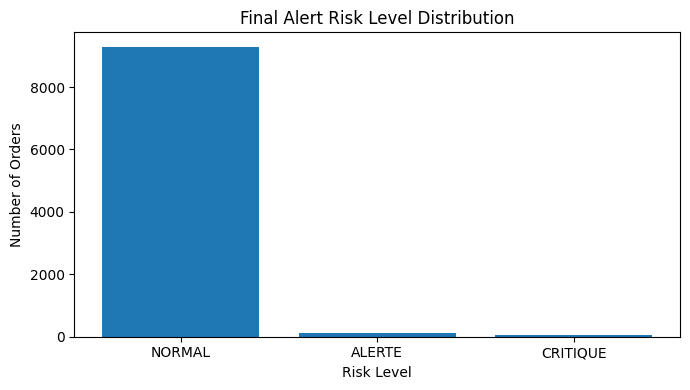

In [7]:

risk_summary = (
    final_alerts
    .groupby('risk_level')
    .agg(
        n_orders=('order_id', 'count'),
        avg_score=(score_col, 'mean'),
        anomalies=('is_anomaly', 'sum') if 'is_anomaly' in final_alerts.columns else ('order_id', 'count')
    )
    .reset_index()
)
risk_summary['share_of_orders'] = risk_summary['n_orders'] / len(final_alerts)
if 'anomalies' in risk_summary.columns:
    risk_summary['precision_within_level'] = risk_summary['anomalies'] / risk_summary['n_orders']

risk_summary.to_csv(EXPORT_DIR / 'risk_level_summary.csv', index=False)
display(risk_summary)

plt.figure(figsize=(7, 4))
order = ['NORMAL', 'ALERTE', 'CRITIQUE']
plot_data = risk_summary.set_index('risk_level').reindex(order).dropna().reset_index()
plt.bar(plot_data['risk_level'], plot_data['n_orders'])
plt.title('Final Alert Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'final_risk_level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Per-anomaly-type recall for the selected model

,model,anomaly_type,n_cases,recall
0,Random Forest,basket_size_outlier,30,1.000000
1,Random Forest,odd_hour,32,1.000000
2,Random Forest,price_tampering,27,1.000000
3,Random Forest,shift_end_void_cluster,15,1.000000
4,Random Forest,suspicious_discount,38,1.000000
5,Random Forest,void_after_payment,34,0.676471


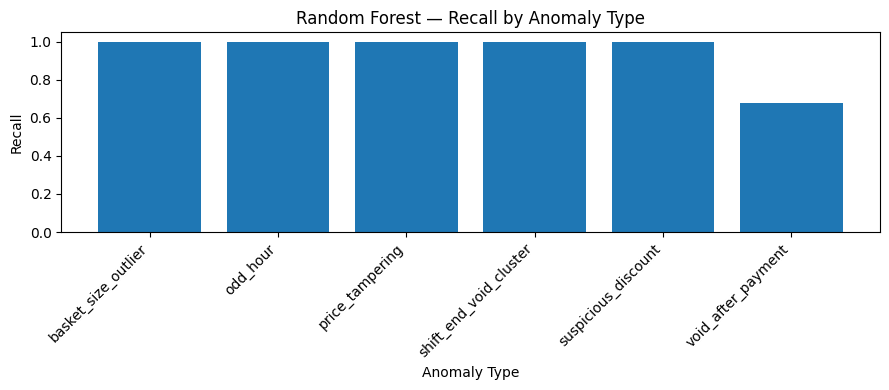

In [8]:

if not sup_per_type.empty:
    selected_per_type = sup_per_type[sup_per_type['model'].eq(FINAL_MODEL_NAME)].copy()
    selected_per_type = selected_per_type.sort_values('recall', ascending=False)
    selected_per_type.to_csv(EXPORT_DIR / 'final_model_per_anomaly_type_recall.csv', index=False)
    display(selected_per_type)

    plt.figure(figsize=(9, 4))
    plt.bar(selected_per_type['anomaly_type'], selected_per_type['recall'])
    plt.title(f'{FINAL_MODEL_NAME} — Recall by Anomaly Type')
    plt.xlabel('Anomaly Type')
    plt.ylabel('Recall')
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'final_model_recall_by_anomaly_type.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No supervised per-anomaly-type recall file found. Skipping this section.')


## 8. Feature importance for the final supervised model

,model,feature,importance
0,Random Forest,is_odd_hour,0.087758
1,Random Forest,order_hour,0.067973
2,Random Forest,mean_abs_price_deviation_pct,0.062580
3,Random Forest,max_abs_price_deviation_pct,0.062401
4,Random Forest,mean_price_deviation_pct,0.053774
5,Random Forest,void_line_rate,0.048486
6,Random Forest,min_line_total,0.040988
7,Random Forest,void_reason_exists,0.038231
8,Random Forest,is_voided_order,0.037365
9,Random Forest,max_discount_rate,0.032490


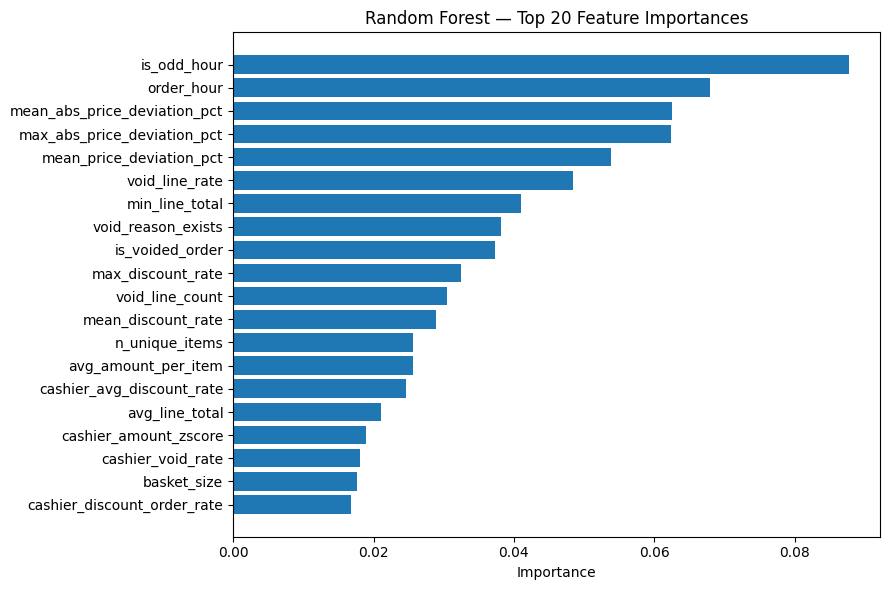

In [9]:

if not sup_feature_importance.empty:
    final_importance = sup_feature_importance[sup_feature_importance['model'].eq(FINAL_MODEL_NAME)].copy()
    if not final_importance.empty:
        final_importance = final_importance.sort_values('importance', ascending=False)
        final_importance.to_csv(EXPORT_DIR / 'final_model_feature_importance.csv', index=False)
        display(final_importance.head(20))

        top_imp = final_importance.head(20).iloc[::-1]
        plt.figure(figsize=(9, 6))
        plt.barh(top_imp['feature'], top_imp['importance'])
        plt.title(f'{FINAL_MODEL_NAME} — Top 20 Feature Importances')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / 'final_model_feature_importance_top20.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f'No feature importance available for {FINAL_MODEL_NAME}.')
else:
    print('No supervised feature importance file found. Skipping this section.')


## 9. Export final model artifacts and dashboard files

In [10]:

# Save final predictions and dashboard alerts
final_predictions_path = EXPORT_DIR / 'final_model_predictions.csv'
alerts_dashboard_path = EXPORT_DIR / 'final_anomaly_alerts_dashboard.csv'
final_alerts_path = EXPORT_DIR / 'final_anomaly_alerts_full.csv'

final_alerts.to_csv(final_alerts_path, index=False)
alerts_dashboard.to_csv(alerts_dashboard_path, index=False)
final_alerts[final_alerts['model'].eq(FINAL_MODEL_NAME)].to_csv(final_predictions_path, index=False)

# Copy model artifacts if available
copied_artifacts = []
for src_path, dst_name in [
    (SUP_BEST_MODEL_PATH, 'final_anomaly_model.pkl'),
    (SUP_PREPROCESSOR_PATH, 'final_anomaly_preprocessor.pkl'),
    (SUP_METADATA_PATH, 'final_supervised_model_metadata.json'),
]:
    if Path(src_path).exists():
        dst_path = MODEL_DIR / dst_name
        shutil.copy2(src_path, dst_path)
        copied_artifacts.append(str(dst_path))

final_metadata = {
    'module': 'Module 3 — Anomaly Detection',
    'final_model': FINAL_MODEL_NAME,
    'model_family': 'Supervised',
    'decision_threshold': medium_threshold,
    'critical_threshold': high_threshold,
    'precision': float(final_model_row['precision']),
    'recall': float(final_model_row['recall']),
    'f1': float(final_model_row['f1']),
    'pr_auc': float(final_model_row.get('pr_auc', np.nan)),
    'false_alerts': int(final_model_row.get('false_alerts', -1)),
    'missed_anomalies': int(final_model_row.get('missed_anomalies', -1)),
    'alert_count': int(final_model_row.get('alert_count', -1)),
    'alert_rate': float(final_model_row.get('alert_rate', np.nan)),
    'risk_levels': {
        'NORMAL': f'score < {medium_threshold:.4f}',
        'ALERTE': f'{medium_threshold:.4f} <= score < {high_threshold:.4f}',
        'CRITIQUE': f'score >= {high_threshold:.4f}'
    },
    'exported_files': {
        'final_model_selection_summary': str(EXPORT_DIR / 'final_model_selection_summary.csv'),
        'final_alerts_dashboard': str(alerts_dashboard_path),
        'final_alerts_full': str(final_alerts_path),
        'final_predictions': str(final_predictions_path),
        'risk_level_summary': str(EXPORT_DIR / 'risk_level_summary.csv')
    },
    'copied_model_artifacts': copied_artifacts
}

with open(EXPORT_DIR / 'final_anomaly_module_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(final_metadata, f, indent=2, ensure_ascii=False)

print('Saved final outputs:')
for p in [final_predictions_path, alerts_dashboard_path, final_alerts_path, EXPORT_DIR / 'final_anomaly_module_metadata.json']:
    print(' -', p)
print('\nCopied model artifacts:')
for p in copied_artifacts:
    print(' -', p)


Saved final outputs:
 - ..\Final\exports\final_model_predictions.csv
 - ..\Final\exports\final_anomaly_alerts_dashboard.csv
 - ..\Final\exports\final_anomaly_alerts_full.csv
 - ..\Final\exports\final_anomaly_module_metadata.json

Copied model artifacts:
 - ..\Final\models\final_anomaly_model.pkl
 - ..\Final\models\final_anomaly_preprocessor.pkl
 - ..\Final\models\final_supervised_model_metadata.json


## 10. Final report summary

In [11]:

summary_text = f"""
Final Anomaly Detection Module Summary
-------------------------------------
Selected final model: {FINAL_MODEL_NAME}
Model family: Supervised classification
Decision threshold: {medium_threshold:.4f}
Critical alert threshold: {high_threshold:.4f}

Final test performance:
- Precision: {final_model_row['precision']:.4f}
- Recall: {final_model_row['recall']:.4f}
- F1-score: {final_model_row['f1']:.4f}
- PR-AUC: {final_model_row.get('pr_auc', np.nan):.4f}
- False alerts: {int(final_model_row.get('false_alerts', -1))}
- Missed anomalies: {int(final_model_row.get('missed_anomalies', -1))}

Conclusion:
The supervised model outperformed the unsupervised anomaly detection approaches.
The selected final model provides the best operational balance between detecting suspicious POS transactions and limiting false alerts.
The final alerts table is ready for dashboard integration with risk levels and explanation fields.
"""

print(summary_text)

with open(REPORT_DIR / 'final_anomaly_detection_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)



Final Anomaly Detection Module Summary
-------------------------------------
Selected final model: Random Forest
Model family: Supervised classification
Decision threshold: 0.2545
Critical alert threshold: 0.9724

Final test performance:
- Precision: 0.9649
- Recall: 0.9375
- F1-score: 0.9510
- PR-AUC: 0.9770
- False alerts: 6
- Missed anomalies: 11

Conclusion:
The supervised model outperformed the unsupervised anomaly detection approaches.
The selected final model provides the best operational balance between detecting suspicious POS transactions and limiting false alerts.
The final alerts table is ready for dashboard integration with risk levels and explanation fields.



## 11. Notebook completion check

In [12]:

required_outputs = [
    EXPORT_DIR / 'final_unsupervised_vs_supervised_comparison.csv',
    EXPORT_DIR / 'final_model_selection_summary.csv',
    EXPORT_DIR / 'final_anomaly_alerts_dashboard.csv',
    EXPORT_DIR / 'final_anomaly_alerts_full.csv',
    EXPORT_DIR / 'risk_level_summary.csv',
    EXPORT_DIR / 'final_anomaly_module_metadata.json',
    REPORT_DIR / 'final_anomaly_detection_summary.txt',
]

missing_outputs = [str(p) for p in required_outputs if not p.exists()]
if missing_outputs:
    raise FileNotFoundError(f'Missing expected final outputs: {missing_outputs}')

print('Notebook 04 completed successfully.')
print('Final model:', FINAL_MODEL_NAME)
print('Dashboard alerts:', len(alerts_dashboard))
print('Output folder:', OUTPUT_DIR.resolve())


Notebook 04 completed successfully.
Final model: Random Forest
Dashboard alerts: 171
Output folder: C:\Users\slimc\Desktop\Notebooks\Module 3\Final
